Fall Detection System (YOLO + TensorFlow)
Choose an option:
1. Data Exploration
2. Pose Extraction
3. Feature Engineering
4. Model Development
5. Deploy Model (Real-time)
6. Run Complete Pipeline


Enter choice (1-6):  6



=== Data Exploration ===

Found 0 fall videos
Found 0 workout videos
Analyzing 0 videos...
No video statistics available.

=== Pose Extraction ===

Found 0 fall videos
Found 0 workout videos
YOLO pose model loaded successfully

Processing fall videos...

Processing workout videos...

=== Feature Engineering ===

No videos found in the specified directories

=== Model Development ===

Epoch 1/30


C:\Users\naufa\anaconda3\envs\cv_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.5980 - loss: 0.6923 - precision_1: 0.5551 - recall_1: 0.9687 - val_accuracy: 0.7500 - val_loss: 0.6901 - val_precision_1: 0.6667 - val_recall_1: 1.0000
Epoch 2/30
 6/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6981 - loss: 0.6893 - precision_1: 0.6196 - recall_1: 1.0000

C:\Users\naufa\anaconda3\envs\cv_env\Lib\site-packages\keras\src\callbacks\model_checkpoint.py:209: UserWarning: Can save best model only with val_recall available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7258 - loss: 0.6886 - precision_1: 0.6474 - recall_1: 0.9935 - val_accuracy: 0.7250 - val_loss: 0.6859 - val_precision_1: 0.6452 - val_recall_1: 1.0000
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8100 - loss: 0.6830 - precision_1: 0.7214 - recall_1: 1.0000 - val_accuracy: 0.7250 - val_loss: 0.6794 - val_precision_1: 0.6452 - val_recall_1: 1.0000
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8593 - loss: 0.6728 - precision_1: 0.7970 - recall_1: 0.9773 - val_accuracy: 0.7500 - val_loss: 0.6682 - val_precision_1: 0.6667 - val_recall_1: 1.0000
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8448 - loss: 0.6574 - precision_1: 0.7566 - recall_1: 1.0000 - val_accuracy: 0.7500 - val_loss: 0.6459 - val_precision_1: 0.6667 - val_recall_1: 1.0000
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9088 - loss: 0.6141 - precision_1: 0.8547 - recall_1: 1.0000 - val_accuracy: 0

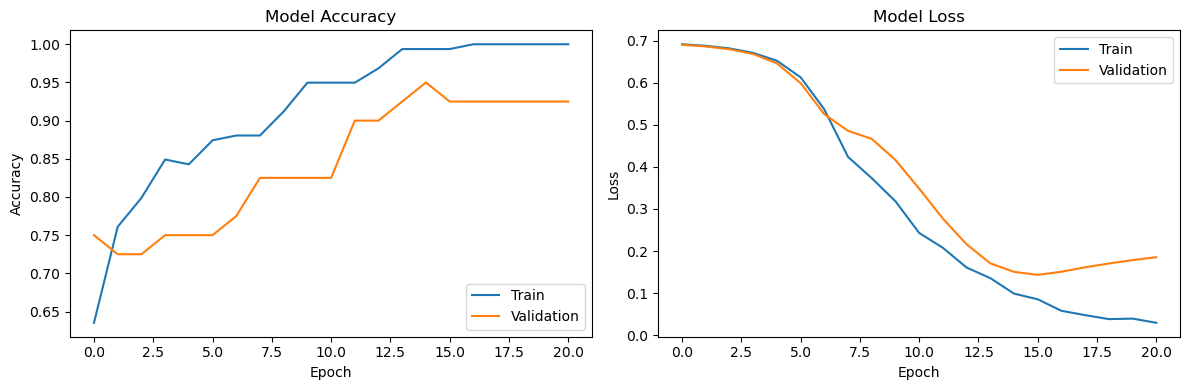


=== Model Deployment ===

YOLO pose model loaded successfully

0: 480x640 1 person, 102.3ms
Speed: 3.1ms preprocess, 102.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 70.9ms
Speed: 1.6ms preprocess, 70.9ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 70.3ms
Speed: 1.2ms preprocess, 70.3ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 71.5ms
Speed: 1.9ms preprocess, 71.5ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 70.4ms
Speed: 1.5ms preprocess, 70.4ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 70.3ms
Speed: 1.4ms preprocess, 70.3ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 71.1ms
Speed: 1.4ms preprocess, 71.1ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)

0: 480x640 1 person, 70.9ms
Speed: 1.0ms preprocess,

KeyboardInterrupt: 

In [4]:
###### Hybrid Fall Detection System
# Combining YOLO Pose Estimation with TensorFlow Sequence Analysis

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from pathlib import Path
from tqdm import tqdm
import pickle
import json
from ultralytics import YOLO

# Global configuration
CONFIG = {
    'IMG_SIZE': (224, 224),
    'SEQUENCE_LENGTH': 20,
    'BATCH_SIZE': 16,
    'EPOCHS': 30,
    'LEARNING_RATE': 0.0001,
    'FALL_THRESHOLD': 0.7
}

# Keypoint names for reference
KEYPOINT_NAMES = [
    "nose", "left_eye", "right_eye", "left_ear", "right_ear", 
    "left_shoulder", "right_shoulder", "left_elbow", "right_elbow", 
    "left_wrist", "right_wrist", "left_hip", "right_hip", 
    "left_knee", "right_knee", "left_ankle", "right_ankle"
]

# Define paths
ROOT_DIR = Path(".")
DATA_DIR = ROOT_DIR / "data"
FALL_DATA_DIR = Path("../data/le2i").absolute()
WORKOUT_VIDEOS_DIR = Path("../data/workout_videos").absolute()
OUTPUTS_DIR = ROOT_DIR / "outputs"
POSE_DATA_DIR = OUTPUTS_DIR / "pose_data"
FEATURES_DIR = OUTPUTS_DIR / "features"
MODELS_DIR = OUTPUTS_DIR / "models"
ANALYSIS_DIR = OUTPUTS_DIR / "analysis"

# Create output directories
for directory in [POSE_DATA_DIR, FEATURES_DIR, MODELS_DIR, ANALYSIS_DIR]:
    os.makedirs(directory, exist_ok=True)
    os.makedirs(directory / "falls", exist_ok=True)
    os.makedirs(directory / "workouts", exist_ok=True)

# 1. Data Exploration Functions

def find_videos(directory, extensions=['.mp4', '.avi', '.mov']):
    """Find video files with specified extensions in directory"""
    if not os.path.exists(directory):
        print(f"Warning: Directory {directory} not found.")
        return []
        
    videos = []
    for ext in extensions:
        try:
            videos.extend(list(Path(directory).rglob(f"*{ext}")))
        except Exception as e:
            print(f"Error finding {ext} files in {directory}: {e}")
    
    return videos

def display_video_frames(video_path, num_frames=6):
    """Display sample frames from a video"""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return
        
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = frame_count / fps
    
    print(f"Video: {os.path.basename(video_path)}")
    print(f"Total frames: {frame_count}")
    print(f"FPS: {fps:.2f}")
    print(f"Duration: {duration:.2f} seconds")
    
    # Get evenly spaced frame indices
    indices = np.linspace(0, frame_count-1, num_frames, dtype=int)
    
    # Create a figure to display frames
    fig, axes = plt.subplots(1, num_frames, figsize=(20, 4))
    
    for i, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            # Convert BGR to RGB
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            axes[i].imshow(frame)
            axes[i].set_title(f"Frame {idx}")
            axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    cap.release()

def get_video_stats(video_path):
    """Get basic statistics for a video file"""
    # Convert string to Path object if it's not already
    if isinstance(video_path, str):
        video_path = Path(video_path)
    
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return None
        
    stats = {
        'path': str(video_path),
        'filename': video_path.name,
        'category': video_path.parent.name,
        'frames': int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        'width': int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        'height': int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        'fps': cap.get(cv2.CAP_PROP_FPS),
    }
    
    stats['duration'] = stats['frames'] / stats['fps'] if stats['fps'] > 0 else 0
    stats['resolution'] = f"{stats['width']}x{stats['height']}"
    
    cap.release()
    return stats

def analyze_dataset():
    """Analyze video datasets and statistics"""
    # Find videos in dataset directories
    fall_videos = find_videos(FALL_VIDEOS_DIR)
    workout_videos = find_videos(WORKOUT_VIDEOS_DIR)
    
    print(f"Found {len(fall_videos)} fall videos")
    print(f"Found {len(workout_videos)} workout videos")
    
    # Display sample videos
    if fall_videos:
        for i in range(min(2, len(fall_videos))):
            display_video_frames(fall_videos[i])
    
    if workout_videos:
        for i in range(min(2, len(workout_videos))):
            display_video_frames(workout_videos[i])
    
    # Collect statistics for all videos
    all_videos = fall_videos + workout_videos
    video_stats = []
    
    print(f"Analyzing {len(all_videos)} videos...")
    for video in all_videos:
        stats = get_video_stats(video)
        if stats:
            # Add dataset type
            if video in fall_videos:
                stats['dataset'] = 'fall'
            else:
                stats['dataset'] = 'workout'
            video_stats.append(stats)
    
    # Create DataFrame
    if video_stats:
        stats_df = pd.DataFrame(video_stats)
        
        # Display summary statistics
        print("\nVideo Dataset Summary:")
        print(f"Total videos: {len(stats_df)}")
        print(f"Fall videos: {len(stats_df[stats_df['dataset'] == 'fall'])}")
        print(f"Workout videos: {len(stats_df[stats_df['dataset'] == 'workout'])}")
        
        # Duration statistics
        print("\nDuration Statistics (seconds):")
        duration_by_dataset = stats_df.groupby('dataset')['duration'].agg(['min', 'max', 'mean', 'median'])
        print(duration_by_dataset)
        
        # Resolution statistics
        print("\nCommon Resolutions:")
        resolution_counts = stats_df['resolution'].value_counts()
        print(resolution_counts.head(5))
        
        # FPS statistics
        print("\nFPS Statistics:")
        fps_by_dataset = stats_df.groupby('dataset')['fps'].agg(['min', 'max', 'mean', 'median'])
        print(fps_by_dataset)
        
        # Plot duration distribution
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1)
        stats_df.boxplot(column='duration', by='dataset')
        plt.title('Video Duration by Dataset')
        plt.suptitle('')  # Remove pandas-generated title
        plt.ylabel('Duration (seconds)')
        
        plt.subplot(1, 2, 2)
        stats_df.boxplot(column='frames', by='dataset')
        plt.title('Frame Count by Dataset')
        plt.suptitle('')
        plt.ylabel('Number of Frames')
        
        plt.tight_layout()
        plt.show()
        
        return stats_df
    else:
        print("No video statistics available.")
        return None

# 2. Pose Extraction with YOLO

def load_yolo_pose_model():
    """Load YOLOv8 pose estimation model"""
    try:
        model = YOLO('yolov8n-pose.pt')
        print("YOLO pose model loaded successfully")
        return model
    except Exception as e:
        print(f"Error loading YOLO pose model: {e}")
        return None

def extract_poses_from_video(video_path, pose_model, output_file=None, dataset_type='unknown'):
    """
    Extract pose keypoints from a video using YOLO pose model
    
    Args:
        video_path: Path to the video file
        pose_model: YOLO pose model
        output_file: Path to save extracted poses (optional)
        dataset_type: Type of the dataset (fall/workout)
        
    Returns:
        Dictionary with extracted poses and metadata
    """
    # Initialize video capture
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    print(f"Processing video: {os.path.basename(video_path)}")
    print(f"Frames: {frame_count}, FPS: {fps}")
    
    # Initialize data structure
    pose_data = {
        'video_path': str(video_path),
        'fps': fps,
        'frame_count': frame_count,
        'width': video_width,
        'height': video_height,
        'dataset_type': dataset_type,
        'frames': []
    }
    
    # Process frames
    frame_idx = 0
    with tqdm(total=frame_count, desc="Extracting poses") as pbar:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            
            # Process every 2nd frame to reduce computation
            if frame_idx % 2 == 0:
                # Run pose detection
                results = pose_model(frame)
                
                # Extract people keypoints
                people = []
                if results and len(results) > 0 and hasattr(results[0], 'keypoints'):
                    keypoints_data = results[0].keypoints.data
                    
                    for person_idx in range(len(keypoints_data)):
                        keypoints = keypoints_data[person_idx].cpu().numpy().tolist()
                        
                        # Convert keypoints to the expected format
                        formatted_keypoints = []
                        for kp_idx, kp in enumerate(keypoints):
                            if kp_idx < len(KEYPOINT_NAMES):
                                # Each keypoint: [x, y, confidence]
                                formatted_keypoints.append([kp[0], kp[1], kp[2]])
                        
                        people.append({
                            'keypoints': formatted_keypoints,
                            'bbox': results[0].boxes.xyxy[person_idx].cpu().numpy().tolist() if hasattr(results[0], 'boxes') else []
                        })
                
                # Add frame to pose data
                pose_data['frames'].append({
                    'frame_idx': frame_idx,
                    'timestamp': frame_idx / fps,
                    'people': people
                })
            
            frame_idx += 1
            pbar.update(1)
    
    # Release resources
    cap.release()
    
    # Save to file if output path provided
    if output_file:
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        with open(output_file, 'w') as f:
            json.dump(pose_data, f, indent=2)
        print(f"Pose data saved to {output_file}")
    
    return pose_data

def batch_process_videos(video_paths, dataset_type, pose_model=None):
    """
    Process a batch of videos to extract poses
    
    Args:
        video_paths: List of video file paths
        dataset_type: Type of dataset (fall/workout)
        pose_model: YOLO pose model (loads if None)
    
    Returns:
        List of output file paths
    """
    # Load YOLO pose model if not provided
    if pose_model is None:
        pose_model = load_yolo_pose_model()
        if pose_model is None:
            return []
    
    output_files = []
    
    for video_path in video_paths:
        # Define output file path
        video_name = os.path.splitext(os.path.basename(video_path))[0]
        output_file = POSE_DATA_DIR / dataset_type / f"{video_name}_poses.json"
        
        # Skip if already processed
        if os.path.exists(output_file):
            print(f"Skipping {video_path} (already processed)")
            output_files.append(output_file)
            continue
        
        # Extract poses
        pose_data = extract_poses_from_video(
            video_path, 
            pose_model, 
            output_file=output_file,
            dataset_type=dataset_type
        )
        
        if pose_data:
            output_files.append(output_file)
    
    return output_files

def process_all_videos():
    """Process all videos in the dataset to extract poses"""
    # Find videos
    fall_videos = find_videos(FALL_VIDEOS_DIR)
    workout_videos = find_videos(WORKOUT_VIDEOS_DIR)
    
    print(f"Found {len(fall_videos)} fall videos")
    print(f"Found {len(workout_videos)} workout videos")
    
    # Load YOLO pose model once for all videos
    pose_model = load_yolo_pose_model()
    if pose_model is None:
        return
    
    # Process fall videos
    print("\nProcessing fall videos...")
    fall_output_files = batch_process_videos(fall_videos, 'falls', pose_model)
    
    # Process workout videos
    print("\nProcessing workout videos...")
    workout_output_files = batch_process_videos(workout_videos, 'workouts', pose_model)
    
    return fall_output_files, workout_output_files

# 3. Feature Engineering Functions

def load_pose_data(dataset_type):
    """Load all pose data JSON files for a given dataset type"""
    dataset_dir = POSE_DATA_DIR / dataset_type
    if not dataset_dir.exists():
        print(f"Warning: Directory {dataset_dir} does not exist!")
        return []
    
    pose_files = list(dataset_dir.glob("*.json"))
    print(f"Found {len(pose_files)} pose data files in {dataset_dir}")
    
    pose_data_list = []
    for file_path in tqdm(pose_files, desc=f"Loading {dataset_type} pose data"):
        try:
            with open(file_path, 'r') as f:
                data = json.load(f)
                # Add label to the data
                data['label'] = dataset_type
                pose_data_list.append(data)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")
    
    return pose_data_list

def calculate_joint_angles(keypoints):
    """
    Calculate joint angles from keypoints
    
    Args:
        keypoints: List of keypoints [x, y, confidence]
    
    Returns:
        Dictionary of joint angles in degrees
    """
    # Define joint triplets for angle calculation (joint, center, joint)
    joint_triplets = {
        'right_elbow': (5, 7, 9),    # right shoulder, elbow, wrist
        'left_elbow': (6, 8, 10),    # left shoulder, elbow, wrist
        'right_shoulder': (3, 5, 7),  # right ear, shoulder, elbow
        'left_shoulder': (4, 6, 8),   # left ear, shoulder, elbow
        'right_hip': (5, 11, 13),     # right shoulder, hip, knee
        'left_hip': (6, 12, 14),      # left shoulder, hip, knee
        'right_knee': (11, 13, 15),   # right hip, knee, ankle
        'left_knee': (12, 14, 16),    # left hip, knee, ankle
        'neck': (5, 0, 6)             # right shoulder, nose, left shoulder
    }
    
    angles = {}
    
    # Check if keypoints is a valid list
    if not isinstance(keypoints, list) or len(keypoints) < 17:
        return angles
    
    for joint_name, (p1_idx, p2_idx, p3_idx) in joint_triplets.items():
        # Check if indices are valid
        if max(p1_idx, p2_idx, p3_idx) >= len(keypoints):
            angles[joint_name] = np.nan
            continue
            
        # Check if keypoints have the right format
        try:
            # Skip if any keypoint has low confidence
            if (len(keypoints[p1_idx]) < 3 or len(keypoints[p2_idx]) < 3 or len(keypoints[p3_idx]) < 3 or
                keypoints[p1_idx][2] < 0.5 or keypoints[p2_idx][2] < 0.5 or keypoints[p3_idx][2] < 0.5):
                angles[joint_name] = np.nan
                continue
            
            # Get coordinates
            p1 = keypoints[p1_idx][:2]  # First point
            p2 = keypoints[p2_idx][:2]  # Center point (the joint)
            p3 = keypoints[p3_idx][:2]  # Third point
            
            # Calculate vectors
            v1 = np.array([p1[0] - p2[0], p1[1] - p2[1]])
            v2 = np.array([p3[0] - p2[0], p3[1] - p2[1]])
            
            # Normalize vectors
            v1_norm = np.linalg.norm(v1)
            v2_norm = np.linalg.norm(v2)
            
            if v1_norm == 0 or v2_norm == 0:
                angles[joint_name] = np.nan
                continue
            
            v1 = v1 / v1_norm
            v2 = v2 / v2_norm
            
            # Calculate dot product and angle
            dot_product = np.clip(np.dot(v1, v2), -1.0, 1.0)
            angle = np.arccos(dot_product) * 180 / np.pi
            
            angles[joint_name] = angle
            
        except Exception as e:
            angles[joint_name] = np.nan
    
    return angles

def calculate_bounding_box(keypoints):
    """
    Calculate the bounding box of the pose
    
    Args:
        keypoints: List of keypoints [x, y, confidence]
    
    Returns:
        Dictionary with bounding box properties: x, y, width, height, aspect_ratio
    """
    # Filter valid keypoints
    valid_x = []
    valid_y = []
    
    for kp in keypoints:
        if len(kp) >= 3 and kp[2] >= 0.5:
            valid_x.append(kp[0])
            valid_y.append(kp[1])
    
    if not valid_x or not valid_y:
        return {
            'x': np.nan, 'y': np.nan, 
            'width': np.nan, 'height': np.nan, 
            'area': np.nan, 'aspect_ratio': np.nan
        }
    
    # Calculate bounding box
    min_x = min(valid_x)
    max_x = max(valid_x)
    min_y = min(valid_y)
    max_y = max(valid_y)
    
    width = max_x - min_x
    height = max_y - min_y
    area = width * height
    aspect_ratio = width / height if height > 0 else np.nan
    
    return {
        'x': min_x,
        'y': min_y,
        'width': width,
        'height': height,
        'area': area,
        'aspect_ratio': aspect_ratio
    }

def calculate_velocity(positions, fps):
    """
    Calculate velocity from position data
    
    Args:
        positions: List of position values over time
        fps: Frames per second
    
    Returns:
        List of velocities
    """
    if len(positions) < 2:
        return []
    
    # Convert to numpy array for easier processing
    positions = np.array(positions)
    
    # Replace NaN with previous valid value for calculation
    nan_mask = np.isnan(positions)
    positions_cleaned = positions.copy()
    
    # Initialize last valid value
    last_valid = None
    
    # Fill NaN values with the last known valid value
    for i in range(len(positions)):
        if nan_mask[i]:
            if last_valid is not None:
                positions_cleaned[i] = last_valid
        else:
            last_valid = positions[i]
    
    # Calculate velocity (change in position per second)
    velocities = np.diff(positions_cleaned) * fps
    
    # Add 0 as first velocity for consistent length
    return np.concatenate(([0], velocities)).tolist()

def calculate_acceleration(velocities, fps):
    """
    Calculate acceleration from velocity data
    
    Args:
        velocities: List of velocity values over time
        fps: Frames per second
    
    Returns:
        List of accelerations
    """
    if len(velocities) < 2:
        return []
    
    # Convert to numpy array for easier processing
    velocities = np.array(velocities)
    
    # Replace NaN with previous valid value for calculation
    nan_mask = np.isnan(velocities)
    velocities_cleaned = velocities.copy()
    
    # Initialize last valid value
    last_valid = None
    
    # Fill NaN values with the last known valid value
    for i in range(len(velocities)):
        if nan_mask[i]:
            if last_valid is not None:
                velocities_cleaned[i] = last_valid
        else:
            last_valid = velocities[i]
    
    # Calculate acceleration (change in velocity per second)
    accelerations = np.diff(velocities_cleaned) * fps
    
    # Add 0 as first acceleration for consistent length
    return np.concatenate(([0], accelerations)).tolist()

def smooth_signal(data, window_size=5):
    """
    Apply smoothing to a signal
    
    Args:
        data: Time series data
        window_size: Size of the moving average window
    
    Returns:
        Smoothed data
    """
    if len(data) < window_size:
        return data
    
    # Convert to numpy array for easier processing
    data = np.array(data)
    
    # Handle NaN values
    nan_mask = np.isnan(data)
    
    # If all values are NaN, return same array
    if np.all(nan_mask):
        return data.tolist()
    
    # Create a copy for processing
    data_cleaned = data.copy()
    
    # Fill NaN values with interpolation where possible
    if np.any(nan_mask):
        # Initialize last valid value
        last_valid = None
        
        # Forward fill
        for i in range(len(data)):
            if nan_mask[i]:
                if last_valid is not None:
                    data_cleaned[i] = last_valid
            else:
                last_valid = data[i]
    
    # Create a moving average kernel
    kernel = np.ones(window_size) / window_size
    
    # Apply convolution for smoothing
    smoothed_data = np.convolve(data_cleaned, kernel, mode='same')
    
    # Handle edge effects
    half_window = window_size // 2
    smoothed_data[:half_window] = data_cleaned[:half_window]
    smoothed_data[-half_window:] = data_cleaned[-half_window:]
    
    return smoothed_data.tolist()

def calculate_vertical_displacement(keypoints_sequence, fps):
    """
    Calculate vertical displacement features for fall detection
    
    Args:
        keypoints_sequence: List of keypoints over time
        fps: Frames per second
    
    Returns:
        Dictionary of vertical displacement features
    """
    # Track center of upper body (nose, shoulders) over time
    upper_body_y = []
    center_y = []
    
    for frame_keypoints in keypoints_sequence:
        # Upper body markers (nose, shoulders)
        upper_markers = [0, 5, 6]  # Indices for nose, right shoulder, left shoulder
        
        # Calculate average y-position of upper body
        valid_y = []
        for idx in upper_markers:
            if idx < len(frame_keypoints) and len(frame_keypoints[idx]) >= 3 and frame_keypoints[idx][2] >= 0.5:
                valid_y.append(frame_keypoints[idx][1])
        
        if valid_y:
            upper_body_y.append(np.mean(valid_y))
        else:
            upper_body_y.append(np.nan)
        
        # Calculate overall center y-position (average of all keypoints)
        valid_center_y = []
        for kp in frame_keypoints:
            if len(kp) >= 3 and kp[2] >= 0.5:
                valid_center_y.append(kp[1])
        
        if valid_center_y:
            center_y.append(np.mean(valid_center_y))
        else:
            center_y.append(np.nan)
    
    # Smooth the trajectories to reduce noise
    upper_body_y = smooth_signal(upper_body_y, window_size=min(5, len(upper_body_y)))
    center_y = smooth_signal(center_y, window_size=min(5, len(center_y)))
    
    # Calculate velocity and acceleration
    upper_body_velocity_y = calculate_velocity(upper_body_y, fps)
    upper_body_accel_y = calculate_acceleration(upper_body_velocity_y, fps)
    
    center_velocity_y = calculate_velocity(center_y, fps)
    center_accel_y = calculate_acceleration(center_velocity_y, fps)
    
    # Calculate maximum values and rates of change
    max_upper_vel = np.nanmax(np.abs(upper_body_velocity_y)) if upper_body_velocity_y and not np.all(np.isnan(upper_body_velocity_y)) else np.nan
    max_upper_acc = np.nanmax(np.abs(upper_body_accel_y)) if upper_body_accel_y and not np.all(np.isnan(upper_body_accel_y)) else np.nan
    
    max_center_vel = np.nanmax(np.abs(center_velocity_y)) if center_velocity_y and not np.all(np.isnan(center_velocity_y)) else np.nan
    max_center_acc = np.nanmax(np.abs(center_accel_y)) if center_accel_y and not np.all(np.isnan(center_accel_y)) else np.nan
    
    # Calculate total vertical displacement (first to last frame)
    if len(upper_body_y) > 1:
        # Find first and last valid values
        valid_indices = [i for i, y in enumerate(upper_body_y) if not np.isnan(y)]
        if valid_indices:
            first_idx = valid_indices[0]
            last_idx = valid_indices[-1]
            upper_body_displacement = upper_body_y[last_idx] - upper_body_y[first_idx]
        else:
            upper_body_displacement = 0.0
    else:
        upper_body_displacement = 0.0
    
    if len(center_y) > 1:
        # Find first and last valid values
        valid_indices = [i for i, y in enumerate(center_y) if not np.isnan(y)]
        if valid_indices:
            first_idx = valid_indices[0]
            last_idx = valid_indices[-1]
            center_displacement = center_y[last_idx] - center_y[first_idx]
        else:
            center_displacement = 0.0
    else:
        center_displacement = 0.0
    
    return {
        'upper_body_y_trajectory': upper_body_y,
        'center_y_trajectory': center_y,
        'upper_body_velocity_y': upper_body_velocity_y,
        'upper_body_accel_y': upper_body_accel_y,
        'center_velocity_y': center_velocity_y,
        'center_accel_y': center_accel_y,
        'max_upper_body_velocity_y': max_upper_vel,
        'max_upper_body_accel_y': max_upper_acc,
        'max_center_velocity_y': max_center_vel,
        'max_center_accel_y': max_center_acc,
        'upper_body_vertical_displacement': upper_body_displacement,
        'center_vertical_displacement': center_displacement
    }

def analyze_pose_collapse(keypoints_sequence, fps):
    """
    Analyze pose collapse patterns (typical in falls)
    
    Args:
        keypoints_sequence: List of keypoints over time
        fps: Frames per second
    
    Returns:
        Dictionary of pose collapse features
    """
    # Initialize default return for safety
    default_collapse = {
        'height_trajectory': [],
        'width_trajectory': [],
        'aspect_ratio_trajectory': [],
        'height_reduction_pct': 0.0,
        'aspect_ratio_increase_pct': 0.0,
        'max_height_collapse_velocity': 0.0,
        'max_aspect_ratio_change_velocity': 0.0
    }
    
    # Skip if sequence is too short
    if len(keypoints_sequence) < 3:
        return default_collapse
    
    # Track body proportions over time
    height_values = []  # Vertical height
    width_values = []   # Horizontal width
    aspect_ratios = []  # Width/height ratio
    
    for frame_keypoints in keypoints_sequence:
        # Calculate bounding box
        bbox = calculate_bounding_box(frame_keypoints)
        
        height_values.append(bbox['height'])
        width_values.append(bbox['width'])
        aspect_ratios.append(bbox['aspect_ratio'])
    
    # Replace NaN values with interpolation
    height_values = smooth_signal(height_values, window_size=min(5, len(height_values)))
    width_values = smooth_signal(width_values, window_size=min(5, len(width_values)))
    aspect_ratios = smooth_signal(aspect_ratios, window_size=min(5, len(aspect_ratios)))
    
    # Calculate relative changes
    if len(height_values) > 1:
        # Find valid values for first frame
        valid_height_indices = [i for i, h in enumerate(height_values) if not np.isnan(h) and h > 0]
        valid_ar_indices = [i for i, ar in enumerate(aspect_ratios) if not np.isnan(ar) and ar > 0]
        
        if valid_height_indices and valid_height_indices[0] < len(height_values) - 1:
            # Use first valid height as reference
            first_height_idx = valid_height_indices[0]
            first_height = height_values[first_height_idx]
            
            # Find minimum height after first valid frame
            later_heights = height_values[first_height_idx+1:]
            if later_heights:
                min_height = min([h for h in later_heights if not np.isnan(h) and h > 0], default=first_height)
                
                # Calculate percentage reduction
                if first_height > 0:
                    height_reduction = (first_height - min_height) / first_height
                else:
                    height_reduction = 0.0
            else:
                height_reduction = 0.0
        else:
            height_reduction = 0.0
        
        # Calculate aspect ratio increase similarly
        if valid_ar_indices and valid_ar_indices[0] < len(aspect_ratios) - 1:
            # Use first valid aspect ratio as reference
            first_ar_idx = valid_ar_indices[0]
            first_ar = aspect_ratios[first_ar_idx]
            
            # Find maximum aspect ratio after first valid frame
            later_ars = aspect_ratios[first_ar_idx+1:]
            if later_ars:
                max_ar = max([ar for ar in later_ars if not np.isnan(ar) and ar > 0], default=first_ar)
                
                # Calculate percentage increase
                if first_ar > 0:
                    ar_increase = (max_ar - first_ar) / first_ar
                else:
                    ar_increase = 0.0
            else:
                ar_increase = 0.0
        else:
            ar_increase = 0.0
    else:
        height_reduction = 0.0
        ar_increase = 0.0
    
    # Calculate velocities for changes
    height_velocity = calculate_velocity(height_values, fps)
    aspect_ratio_velocity = calculate_velocity(aspect_ratios, fps)
    
    # Calculate maximum rate of change
    if height_velocity and not np.all(np.isnan(height_velocity)):
        # Find most negative velocity (fastest collapse)
        valid_height_vel = [v for v in height_velocity if not np.isnan(v)]
        max_height_velocity = min(valid_height_vel, default=0.0)  # Negative for collapse
    else:
        max_height_velocity = 0.0
    
    if aspect_ratio_velocity and not np.all(np.isnan(aspect_ratio_velocity)):
        # Find most positive velocity (fastest widening)
        valid_ar_vel = [v for v in aspect_ratio_velocity if not np.isnan(v)]
        max_ar_velocity = max(valid_ar_vel, default=0.0)  # Positive for collapse
    else:
        max_ar_velocity = 0.0
    
    return {
        'height_trajectory': height_values,
        'width_trajectory': width_values,
        'aspect_ratio_trajectory': aspect_ratios,
        'height_reduction_pct': height_reduction * 100,  # Convert to percentage
        'aspect_ratio_increase_pct': ar_increase * 100,  # Convert to percentage
        'max_height_collapse_velocity': max_height_velocity,
        'max_aspect_ratio_change_velocity': max_ar_velocity
    }

def detect_impact(keypoints_sequence, fps, threshold=2.0):
    """
    Detect potential impact events in the sequence
    
    Args:
        keypoints_sequence: List of keypoints over time
        fps: Frames per second
        threshold: Acceleration threshold (in units/s²) for impact detection
    
    Returns:
        Dictionary of impact features
    """
    # Initialize default return for safety
    default_impact = {
        'has_impact': False,
        'impact_count': 0,
        'max_deceleration': 0.0,
        'impact_frame': 0,
        'impact_body_part': None
    }
    
    # Skip if sequence is too short
    if len(keypoints_sequence) < 3:
        return default_impact
    
    # Track body parts likely to impact during a fall
    tracked_keypoints = {
        'head': 0,  # nose
        'hip_center': None,  # will calculate as average of left and right hip
        'knee_center': None,  # will calculate as average of left and right knee
    }
    
    # Track positions over time
    trajectories = {part: {'x': [], 'y': []} for part in tracked_keypoints}
    
    for frame_keypoints in keypoints_sequence:
        # Process single keypoints
        for part, idx in tracked_keypoints.items():
            if idx is not None:
                if idx < len(frame_keypoints) and len(frame_keypoints[idx]) >= 3 and frame_keypoints[idx][2] >= 0.5:
                    trajectories[part]['x'].append(frame_keypoints[idx][0])
                    trajectories[part]['y'].append(frame_keypoints[idx][1])
                else:
                    trajectories[part]['x'].append(np.nan)
                    trajectories[part]['y'].append(np.nan)
        
        # Calculate hip center
        left_hip_idx, right_hip_idx = 12, 11  # left hip, right hip
        if (left_hip_idx < len(frame_keypoints) and right_hip_idx < len(frame_keypoints) and
            len(frame_keypoints[left_hip_idx]) >= 3 and len(frame_keypoints[right_hip_idx]) >= 3 and
            frame_keypoints[left_hip_idx][2] >= 0.5 and frame_keypoints[right_hip_idx][2] >= 0.5):
            hip_center_x = (frame_keypoints[left_hip_idx][0] + frame_keypoints[right_hip_idx][0]) / 2
            hip_center_y = (frame_keypoints[left_hip_idx][1] + frame_keypoints[right_hip_idx][1]) / 2
            trajectories['hip_center']['x'].append(hip_center_x)
            trajectories['hip_center']['y'].append(hip_center_y)
        else:
            trajectories['hip_center']['x'].append(np.nan)
            trajectories['hip_center']['y'].append(np.nan)
        
        # Calculate knee center
        left_knee_idx, right_knee_idx = 14, 13  # left knee, right knee
        if (left_knee_idx < len(frame_keypoints) and right_knee_idx < len(frame_keypoints) and
            len(frame_keypoints[left_knee_idx]) >= 3 and len(frame_keypoints[right_knee_idx]) >= 3 and
            frame_keypoints[left_knee_idx][2] >= 0.5 and frame_keypoints[right_knee_idx][2] >= 0.5):
            knee_center_x = (frame_keypoints[left_knee_idx][0] + frame_keypoints[right_knee_idx][0]) / 2
            knee_center_y = (frame_keypoints[left_knee_idx][1] + frame_keypoints[right_knee_idx][1]) / 2
            trajectories['knee_center']['x'].append(knee_center_x)
            trajectories['knee_center']['y'].append(knee_center_y)
        else:
            trajectories['knee_center']['x'].append(np.nan)
            trajectories['knee_center']['y'].append(np.nan)
    
    # Check if we have any valid trajectory data
    has_valid_data = False
    for part in trajectories:
        for coord in ['x', 'y']:
            # Check if there's at least one valid (non-NaN) value
            if any(not np.isnan(val) for val in trajectories[part][coord]):
                has_valid_data = True
                break
        if has_valid_data:
            break
    
    # Return default if no valid data
    if not has_valid_data:
        return default_impact
    
    # Smooth trajectories
    for part in trajectories:
        for coord in ['x', 'y']:
            trajectories[part][coord] = smooth_signal(
                trajectories[part][coord], 
                window_size=min(5, len(trajectories[part][coord]))
            )
    
    # Calculate velocities and accelerations
    velocities = {part: {'x': None, 'y': None} for part in tracked_keypoints}
    accelerations = {part: {'x': None, 'y': None} for part in tracked_keypoints}
    
    for part in trajectories:
        for coord in ['x', 'y']:
            velocities[part][coord] = calculate_velocity(trajectories[part][coord], fps)
            accelerations[part][coord] = calculate_acceleration(velocities[part][coord], fps)
    
    # Detect impact events (rapid deceleration)
    impact_events = {}
    try:
        for part in accelerations:
            for coord in ['x', 'y']:
                # Skip if acceleration data is empty or all NaN
                if not accelerations[part][coord] or np.all(np.isnan(accelerations[part][coord])):
                    continue
                
                # Convert to numpy array and handle NaN values
                acc_data = np.array(accelerations[part][coord])
                
                # Create a mask for valid values (not NaN)
                valid_mask = ~np.isnan(acc_data)
                
                # Skip if all values are NaN
                if not np.any(valid_mask):
                    continue
                
                # Get valid acceleration values and their indices
                valid_acc = acc_data[valid_mask]
                valid_idx = np.where(valid_mask)[0]
                
                # Find potential impacts (where deceleration exceeds threshold)
                impact_mask = valid_acc < -threshold
                
                # Skip if no impacts found
                if not np.any(impact_mask):
                    continue
                
                # Get indices of potential impacts
                potential_impacts = valid_idx[impact_mask]
                
                if len(potential_impacts) > 0:
                    # Find the maximum deceleration index among potential impacts
                    impact_acc_values = acc_data[potential_impacts]
                    max_decel_idx_rel = np.argmin(impact_acc_values)
                    max_decel_idx = potential_impacts[max_decel_idx_rel]
                    
                    # Check for valid index for velocity before impact
                    vel_idx = max(0, max_decel_idx-1)
                    if vel_idx >= len(velocities[part][coord]):
                        vel_idx = len(velocities[part][coord]) - 1
                    
                    impact_events[f"{part}_{coord}"] = {
                        'frame_idx': int(max_decel_idx),
                        'deceleration': float(acc_data[max_decel_idx]),
                        'velocity_before': float(velocities[part][coord][vel_idx])
                    }
        
        # Calculate summary features
        if impact_events:
            # Find the strongest impact
            try:
                max_part = max(impact_events.items(), key=lambda x: abs(x[1]['deceleration']))
                return {
                    'has_impact': True,
                    'impact_count': len(impact_events),
                    'max_deceleration': max_part[1]['deceleration'],
                    'impact_frame': max_part[1]['frame_idx'],
                    'impact_body_part': max_part[0]
                }
            except Exception as e:
                return default_impact
        else:
            return default_impact
            
    except Exception as e:
        return default_impact

def extract_video_features(pose_data):
    """
    Extract features from video pose data
    
    Args:
        pose_data: Dict with pose data from YOLO pose model
    
    Returns:
        Dictionary of features for fall detection
    """
    print(f"Extracting features from {pose_data.get('video_path', 'unknown')}")
    
    # Skip if no frames
    if 'frames' not in pose_data or not pose_data['frames']:
        print("No frames found, skipping")
        return None
    
    # Get metadata
    video_path = pose_data.get('video_path', 'unknown')
    fps = pose_data.get('fps', 30)  # Default to 30 fps if missing
    total_frames = len(pose_data.get('frames', []))
    
    # Extract main person keypoints over time
    keypoints_sequence = []
    
    for frame in pose_data['frames']:
        people = frame.get('people', [])
        if people and 'keypoints' in people[0]:
            # Use the first person (main subject)
            keypoints = people[0]['keypoints']
            keypoints_sequence.append(keypoints)
    
    # Skip if not enough keypoints frames
    if len(keypoints_sequence) < 5:
        print("Not enough valid keypoints frames, skipping")
        return None
    
    # Calculate features
    try:
        # Calculate static features (joint angles) for each frame
        joint_angles_sequence = []
        
        for keypoints in keypoints_sequence:
            joint_angles = calculate_joint_angles(keypoints)
            joint_angles_sequence.append(joint_angles)
        
        # Calculate temporal features
        vertical_features = calculate_vertical_displacement(keypoints_sequence, fps)
        impact_features = detect_impact(keypoints_sequence, fps)
        collapse_features = analyze_pose_collapse(keypoints_sequence, fps)
        
        # Aggregate joint angle features over time
        joint_angle_features = {}
        for joint in ['right_elbow', 'left_elbow', 'right_knee', 'left_knee', 'right_hip', 'left_hip']:
            # Extract angle values over time (with defaults for missing values)
            angle_values = [frame_angles.get(joint, np.nan) for frame_angles in joint_angles_sequence]
            
            # Calculate statistics
            valid_angles = [val for val in angle_values if not np.isnan(val)]
            
            if valid_angles:
                joint_angle_features[f"{joint}_mean"] = np.mean(valid_angles)
                joint_angle_features[f"{joint}_min"] = np.min(valid_angles)
                joint_angle_features[f"{joint}_max"] = np.max(valid_angles)
                joint_angle_features[f"{joint}_range"] = np.max(valid_angles) - np.min(valid_angles)
                
                # Calculate angle velocities
                angle_velocities = calculate_velocity(angle_values, fps)
                valid_velocities = [val for val in angle_velocities if not np.isnan(val)]
                
                if valid_velocities:
                    joint_angle_features[f"{joint}_max_velocity"] = np.max(np.abs(valid_velocities))
                else:
                    joint_angle_features[f"{joint}_max_velocity"] = 0.0
            else:
                # Provide defaults
                joint_angle_features[f"{joint}_mean"] = 0.0
                joint_angle_features[f"{joint}_min"] = 0.0
                joint_angle_features[f"{joint}_max"] = 0.0
                joint_angle_features[f"{joint}_range"] = 0.0
                joint_angle_features[f"{joint}_max_velocity"] = 0.0
        
        # Combine all features
        features = {
            'metadata': {
                'video_path': video_path,
                'fps': fps,
                'total_frames': total_frames,
                'duration': total_frames / fps if fps > 0 else 0,
                'data_type': 'video'
            },
            'joint_angles': joint_angle_features,
            'vertical_motion': {
                'max_upper_body_velocity_y': vertical_features.get('max_upper_body_velocity_y', 0.0),
                'max_upper_body_accel_y': vertical_features.get('max_upper_body_accel_y', 0.0),
                'max_center_velocity_y': vertical_features.get('max_center_velocity_y', 0.0),
                'max_center_accel_y': vertical_features.get('max_center_accel_y', 0.0),
                'upper_body_vertical_displacement': vertical_features.get('upper_body_vertical_displacement', 0.0),
                'center_vertical_displacement': vertical_features.get('center_vertical_displacement', 0.0),
            },
            'impact': {
                'has_impact': impact_features.get('has_impact', False),
                'impact_count': impact_features.get('impact_count', 0),
                'max_deceleration': impact_features.get('max_deceleration', 0.0),
                'impact_frame': impact_features.get('impact_frame', 0),
                'impact_body_part': impact_features.get('impact_body_part', None),
            },
            'collapse': {
                'height_reduction_pct': collapse_features.get('height_reduction_pct', 0.0),
                'aspect_ratio_increase_pct': collapse_features.get('aspect_ratio_increase_pct', 0.0),
                'max_height_collapse_velocity': collapse_features.get('max_height_collapse_velocity', 0.0),
                'max_aspect_ratio_change_velocity': collapse_features.get('max_aspect_ratio_change_velocity', 0.0)
            }
        }
        
        return features
        
    except Exception as e:
        print(f"Error extracting features: {e}")
        return None

def create_feature_matrix(features_list):
    """
    Convert feature dictionaries to a tabular format suitable for ML
    
    Args:
        features_list: List of feature dictionaries
    
    Returns:
        DataFrame with features in a tabular format
    """
    if not features_list:
        return pd.DataFrame()
    
    rows = []
    
    for features in features_list:
        # Common fields
        row = {
            'label': features['metadata'].get('label', 'unknown')
        }
        
        # Add file path and metadata
        row['file_path'] = features['metadata'].get('video_path', 'unknown')
        row['fps'] = features['metadata'].get('fps', 0)
        row['duration'] = features['metadata'].get('duration', 0)
        row['data_type'] = features['metadata'].get('data_type', 'video')
        
        # Add joint angle features
        for key, value in features.get('joint_angles', {}).items():
            row[key] = value
        
        # Add vertical motion features
        for key, value in features.get('vertical_motion', {}).items():
            row[key] = value
        
        # Add impact features
        for key, value in features.get('impact', {}).items():
            if key != 'impact_body_part':  # Skip non-numeric
                row[key] = value
        
        # Add collapse features
        for key, value in features.get('collapse', {}).items():
            row[key] = value
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Convert boolean columns to int
    bool_cols = df.select_dtypes(include=['bool']).columns
    for col in bool_cols:
        df[col] = df[col].astype(int)
    
    return df

def process_all_datasets():
    """Process all videos, extract features, and prepare dataset for modeling"""
    # Step 1: Find all videos
    fall_videos = find_videos(FALL_VIDEOS_DIR)
    workout_videos = find_videos(WORKOUT_VIDEOS_DIR)
    
    if not fall_videos and not workout_videos:
        print("No videos found in the specified directories")
        return None
    
    # Step 2: Process videos to extract poses (if not already done)
    pose_model = load_yolo_pose_model()
    
    if not os.path.exists(POSE_DATA_DIR / "falls") or not any(os.listdir(POSE_DATA_DIR / "falls")):
        print("Extracting poses from fall videos...")
        batch_process_videos(fall_videos[:5], 'falls', pose_model)  # Process a subset for demo
    
    if not os.path.exists(POSE_DATA_DIR / "workouts") or not any(os.listdir(POSE_DATA_DIR / "workouts")):
        print("Extracting poses from workout videos...")
        batch_process_videos(workout_videos[:5], 'workouts', pose_model)  # Process a subset for demo
    
    # Step 3: Load pose data
    print("Loading extracted pose data...")
    fall_pose_data = load_pose_data("falls")
    workout_pose_data = load_pose_data("workouts")
    
    # Step 4: Extract features
    print("Extracting features from fall videos...")
    fall_features = []
    for pose_data in tqdm(fall_pose_data, desc="Processing fall videos"):
        features = extract_video_features(pose_data)
        if features:
            features['metadata']['label'] = 'fall'
            fall_features.append(features)
    
    print(f"Extracted features from {len(fall_features)}/{len(fall_pose_data)} fall videos")
    
    print("Extracting features from workout videos...")
    workout_features = []
    for pose_data in tqdm(workout_pose_data, desc="Processing workout videos"):
        features = extract_video_features(pose_data)
        if features:
            features['metadata']['label'] = 'workout'
            workout_features.append(features)
    
    print(f"Extracted features from {len(workout_features)}/{len(workout_pose_data)} workout videos")
    
    # Combine all features
    all_features = fall_features + workout_features
    
    # Save all features
    features_file = FEATURES_DIR / "all_features.json"
    with open(features_file, 'w') as f:
        json.dump(all_features, f)
    
    print(f"Saved all features to {features_file}")
    
    # Create tabular dataset for modeling
    feature_df = create_feature_matrix(all_features)
    
    # Save to CSV
    csv_file = FEATURES_DIR / "features_for_modeling.csv"
    feature_df.to_csv(csv_file, index=False)
    print(f"Saved features to {csv_file}")
    
    return feature_df

# 4. Model Development

def normalize_features(feature_df):
    """
    Normalize numeric features for better training
    
    Args:
        feature_df: DataFrame with extracted features
    
    Returns:
        DataFrame with normalized features
    """
    from sklearn.preprocessing import StandardScaler
    
    # Make a copy to avoid modifying the original
    df = feature_df.copy()
    
    # Separate label column
    if 'label' in df.columns:
        label = df['label'].copy()
        df = df.drop('label', axis=1)
    else:
        label = None
    
    # Select only numeric columns (excluding categorical ones)
    exclude_cols = ['file_path', 'data_type', 'impact_body_part']
    exclude_cols = [col for col in exclude_cols if col in df.columns]
    numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
    numeric_cols = [col for col in numeric_cols if col not in exclude_cols]
    
    # Skip if no numeric columns to normalize
    if not numeric_cols:
        return feature_df
    
    # Create a StandardScaler
    scaler = StandardScaler()
    
    # Replace infinite values with NaN
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    # Fill NaN values with appropriate defaults
    for col in numeric_cols:
        df[col] = df[col].fillna(0)
    
    # Scale numeric features
    df[numeric_cols] = scaler.fit_transform(df[numeric_cols])
    
    # Add label back
    if label is not None:
        df['label'] = label
    
    return df

def build_lstm_model(input_shape):
    """
    Build a CNN-LSTM model for fall detection
    
    Args:
        input_shape: Input shape for the model (sequence_length, num_features)
    
    Returns:
        Compiled Keras model
    """
    model = tf.keras.Sequential([
        # LSTM layers
        tf.keras.layers.LSTM(128, return_sequences=True, input_shape=input_shape),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dropout(0.3),
        
        # Dense layers
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['LEARNING_RATE']),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Recall(), tf.keras.metrics.Precision()]
    )
    
    return model

def prepare_sequence_data(feature_df, sequence_length=20):
    """
    Prepare sequence data for LSTM model
    
    Args:
        feature_df: DataFrame with features
        sequence_length: Length of sequences
    
    Returns:
        X_sequences, y (sequences and labels)
    """
    # Group by video file path
    grouped = feature_df.groupby('file_path')
    
    sequences = []
    labels = []
    
    for path, group in grouped:
        # Convert group to numpy array without label and path columns
        exclude_cols = ['label', 'file_path', 'data_type', 'impact_body_part']
        
        # Create feature array
        feature_cols = [col for col in group.columns if col not in exclude_cols]
        features = group[feature_cols].values
        
        # Pad or truncate to sequence_length
        if len(features) > sequence_length:
            # Take evenly spaced subsequences
            indices = np.linspace(0, len(features)-1, sequence_length, dtype=int)
            sequence = features[indices]
        else:
            # Pad with zeros
            sequence = np.zeros((sequence_length, len(feature_cols)))
            sequence[:len(features)] = features
        
        # Add to sequences
        sequences.append(sequence)
        
        # Get label (use most common label in group)
        if 'label' in group.columns:
            label = group['label'].mode()[0]
            if isinstance(label, str):
                label = 1 if label == 'fall' else 0
            labels.append(label)
        else:
            labels.append(0)  # Default to non-fall
    
    return np.array(sequences), np.array(labels)

def train_hybrid_model(feature_df):
    """
    Train the hybrid model for fall detection
    
    Args:
        feature_df: DataFrame with features
    
    Returns:
        Trained model and history
    """
    # Normalize features
    normalized_df = normalize_features(feature_df)
    
    # Prepare sequence data
    X_sequences, y = prepare_sequence_data(normalized_df, CONFIG['SEQUENCE_LENGTH'])
    
    # Split into train/test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_sequences, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Build model
    input_shape = (X_train.shape[1], X_train.shape[2])  # (sequence_length, num_features)
    model = build_lstm_model(input_shape)
    
    # Setup callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ModelCheckpoint(str(MODELS_DIR / 'fall_detection_lstm.h5'), monitor='val_recall', mode='max', save_best_only=True)
    ]
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=CONFIG['EPOCHS'],
        batch_size=CONFIG['BATCH_SIZE'],
        callbacks=callbacks,
        verbose=1
    )
    
    # Evaluate model
    test_results = model.evaluate(X_test, y_test, verbose=1)
    print(f"Test Loss: {test_results[0]:.4f}")
    print(f"Test Accuracy: {test_results[1]:.4f}")
    print(f"Test Recall: {test_results[2]:.4f}")
    print(f"Test Precision: {test_results[3]:.4f}")
    
    # Plot training history
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='lower right')
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.savefig(MODELS_DIR / 'training_history.png')
    plt.show()
    
    return model, history

# 5. Model Integration with YOLO

def build_integrated_model():
    """Build and save the integrated model for deployment"""
    # Create a pipeline with YOLO pose extraction + LSTM
    from sklearn.pipeline import Pipeline
    
    class YOLOPoseExtractor:
        def __init__(self):
            self.pose_model = load_yolo_pose_model()
            self.sequence_length = CONFIG['SEQUENCE_LENGTH']
        
        def fit(self, X, y=None):
            return self
        
        def transform(self, videos):
            # Process each video to extract poses
            pose_sequences = []
            
            for video_path in videos:
                # Extract poses using YOLO
                pose_data = extract_poses_from_video(video_path, self.pose_model)
                
                # Extract features
                features = extract_video_features(pose_data)
                
                # Extract feature values
                feature_values = []
                for category in ['joint_angles', 'vertical_motion', 'impact', 'collapse']:
                    if category in features:
                        for key, value in features[category].items():
                            if isinstance(value, (int, float)) and not isinstance(value, bool):
                                feature_values.append(value)
                            elif isinstance(value, bool):
                                feature_values.append(int(value))
                
                # Add to pose sequences
                pose_sequences.append(feature_values)
            
            # Convert to numpy array and reshape for LSTM
            X = np.array(pose_sequences)
            
            # Reshape to (n_samples, sequence_length, n_features)
            # For single videos, duplicate features to create a sequence
            if X.shape[0] == 1:
                X = np.repeat(X, self.sequence_length, axis=0)
                X = X.reshape(1, self.sequence_length, -1)
            
            return X
    
    # Create pipeline
    integrated_model = Pipeline([
        ('pose_extractor', YOLOPoseExtractor()),
        ('lstm_model', build_lstm_model((CONFIG['SEQUENCE_LENGTH'], 30)))  # Placeholder for feature count
    ])
    
    # Save the model
    with open(MODELS_DIR / 'integrated_model.pkl', 'wb') as f:
        pickle.dump(integrated_model, f)
    
    return integrated_model

def real_time_fall_detection(video_source=0):
    """
    Real-time fall detection using the hybrid model
    
    Args:
        video_source: Camera index or video path
    """
    # Load YOLO pose model
    pose_model = load_yolo_pose_model()
    
    # Load trained LSTM model
    lstm_model = tf.keras.models.load_model(MODELS_DIR / 'fall_detection_lstm.h5')
    
    # Open video capture
    cap = cv2.VideoCapture(video_source)
    if not cap.isOpened():
        print(f"Error: Could not open video source {video_source}")
        return
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Initialize variables for pose tracking
    pose_history = []
    feature_buffer = []
    
    # Font settings for display
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.7
    thickness = 2
    
    # Main processing loop
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        # Run YOLO pose detection
        results = pose_model(frame)
        
        # Process detection results
        if results and len(results) > 0:
            # Draw pose keypoints
            annotated_frame = results[0].plot()
            
            # Extract keypoints
            if hasattr(results[0], 'keypoints') and results[0].keypoints is not None:
                keypoints_data = results[0].keypoints.data
                
                if len(keypoints_data) > 0:
                    keypoints = keypoints_data[0].cpu().numpy().tolist()
                    
                    # Convert keypoints to the expected format
                    formatted_keypoints = []
                    for kp_idx, kp in enumerate(keypoints):
                        if kp_idx < len(KEYPOINT_NAMES):
                            # Each keypoint: [x, y, confidence]
                            formatted_keypoints.append([kp[0], kp[1], kp[2]])
                    
                    # Add to pose history
                    pose_history.append(formatted_keypoints)
                    
                    # Keep only the last N frames
                    if len(pose_history) > CONFIG['SEQUENCE_LENGTH']:
                        pose_history.pop(0)
                    
                    # If we have enough frames, calculate features
                    if len(pose_history) >= 5:  # Minimum frames needed
                        # Calculate features from pose sequence
                        joint_angles = calculate_joint_angles(formatted_keypoints)
                        bbox = calculate_bounding_box(formatted_keypoints)
                        
                        # Calculate more complex features if enough history
                        if len(pose_history) >= 5:
                            vertical_features = calculate_vertical_displacement(pose_history[-5:], fps)
                            collapse_features = analyze_pose_collapse(pose_history[-5:], fps)
                            impact_features = detect_impact(pose_history[-5:], fps)
                            
                            # Create feature vector
                            features = []
                            
                            # Add joint angles
                            for joint in ['right_elbow', 'left_elbow', 'right_knee', 'left_knee', 'right_hip', 'left_hip']:
                                features.append(joint_angles.get(joint, 0))
                            
                            # Add vertical motion features
                            features.append(vertical_features.get('max_upper_body_velocity_y', 0))
                            features.append(vertical_features.get('max_upper_body_accel_y', 0))
                            
                            # Add collapse features
                            features.append(collapse_features.get('height_reduction_pct', 0) / 100)
                            features.append(collapse_features.get('aspect_ratio_increase_pct', 0) / 100)
                            
                            # Add impact features
                            features.append(1 if impact_features.get('has_impact', False) else 0)
                            features.append(impact_features.get('impact_count', 0))
                            
                            # Add to feature buffer
                            feature_buffer.append(features)
                            
                            # Keep only the last N features
                            if len(feature_buffer) > CONFIG['SEQUENCE_LENGTH']:
                                feature_buffer.pop(0)
                            
                            # If we have enough features, make a prediction
                            if len(feature_buffer) == CONFIG['SEQUENCE_LENGTH']:
                                # Prepare input for LSTM
                                X = np.array([feature_buffer])
                                
                                # Make prediction
                                try:
                                    fall_probability = lstm_model.predict(X, verbose=0)[0][0]
                                    
                                    # Display prediction
                                    status = f"Fall probability: {fall_probability:.2f}"
                                    color = (0, 0, 255) if fall_probability > CONFIG['FALL_THRESHOLD'] else (0, 255, 0)
                                    
                                    cv2.putText(annotated_frame, status, (10, 30), font, font_scale, color, thickness)
                                    
                                    # Add alert for fall detection
                                    if fall_probability > CONFIG['FALL_THRESHOLD']:
                                        cv2.putText(annotated_frame, "FALL DETECTED!", (frame_width//4, frame_height//2),
                                                    font, 2, (0, 0, 255), 3)
                                        cv2.rectangle(annotated_frame, (0, 0), (frame_width, frame_height), (0, 0, 255), 10)
                                except Exception as e:
                                    print(f"Prediction error: {e}")
        else:
            annotated_frame = frame
        
        # Display the frame
        cv2.imshow('Fall Detection', annotated_frame)
        
        # Exit on 'q' key press
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
    
    # Release resources
    cap.release()
    cv2.destroyAllWindows()

# 6. Main Functions

def data_exploration():
    """Run data exploration analysis"""
    print("\n=== Data Exploration ===\n")
    stats_df = analyze_dataset()
    return stats_df

def pose_extraction():
    """Run pose extraction on all videos"""
    print("\n=== Pose Extraction ===\n")
    fall_outputs, workout_outputs = process_all_videos()
    return fall_outputs, workout_outputs

def feature_engineering():
    """Run feature engineering on extracted poses"""
    print("\n=== Feature Engineering ===\n")
    feature_df = process_all_datasets()
    return feature_df

def model_development(feature_df=None):
    """Develop and train the fall detection model"""
    print("\n=== Model Development ===\n")
    
    if feature_df is None:
        # Try to load from CSV
        csv_path = FEATURES_DIR / "features_for_modeling.csv"
        if os.path.exists(csv_path):
            feature_df = pd.read_csv(csv_path)
        else:
            print("No feature data found. Run feature_engineering() first.")
            return None
    
    model, history = train_hybrid_model(feature_df)
    return model, history

def deploy_model(video_source=0):
    """Deploy the model for real-time fall detection"""
    print("\n=== Model Deployment ===\n")
    real_time_fall_detection(video_source)

# Main execution
if __name__ == "__main__":
    print("Fall Detection System (YOLO + TensorFlow)")
    print("Choose an option:")
    print("1. Data Exploration")
    print("2. Pose Extraction")
    print("3. Feature Engineering")
    print("4. Model Development")
    print("5. Deploy Model (Real-time)")
    print("6. Run Complete Pipeline")
    
    choice = input("Enter choice (1-6): ")
    
    if choice == '1':
        data_exploration()
    elif choice == '2':
        pose_extraction()
    elif choice == '3':
        feature_engineering()
    elif choice == '4':
        model_development()
    elif choice == '5':
        video_source = input("Enter video source (0 for webcam, or path to video file): ")
        if video_source.isdigit():
            video_source = int(video_source)
        deploy_model(video_source)
    elif choice == '6':
        # Run complete pipeline
        stats_df = data_exploration()
        fall_outputs, workout_outputs = pose_extraction()
        feature_df = feature_engineering()
        model, history = model_development(feature_df)
        deploy_model(0)  # Use webcam
    else:
        print("Invalid choice.")